# The two-box two-point far SOL model

Here, we test the two-box two-point model for near-SOL / far-SOL transport. The model is derived and presented in the main text on overleaf.

Input parameters:

| Parameter | Name | Explanation | Default value |
|-|-|-|-|
|$\nu_*$ | `coll` | Reference collisionality|  |
|$\hat{v}$ | `vhat` | Perpendicular to parallel transport time ratio (ballooning)| |
|$\gamma$ | `gamma` | Sheath heat transmission coefficient | 7 | 
|$\tau$ | `tau` | Ion to electron temperature ratio | 2 (set to 0 for cold ions) | 
|$\sqrt{m_e/\mu}$|`sqmass`| Square root of electron to total mass ratio | 0.023 (deuterium)|
|$\delta/L_\parallel$|`doL`| Normalized parallel decay length of far-SOL sources (assumed small) |  |

__OLD__

and $T_t$ and $T_u$ are both normalized to a reference temperature $T_0$. Taking $L_\parallel \sim 10 m$, $c_s \sim 10^4 m/s$ and $\tau_d \sim 10 \mu s$ we typically have normalized $\tau_d \sim 10^{-2}$.


We take $q$ to be an FPP with $\Gamma$-2 pulse shape, and $Q, q_\parallel$ are parameters. The pulse duration time is a free parameter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar, minimize

In [ ]:
def plot_far_sol_condition(coll_arr,vhat_arr,gamma=7,tau=1,doL=1./3.,sqmass=0.023):
    tautmp = (1+tau)
    xi = 7*tautmp**1.5*sqmass*coll_arr/(3.2*2)
    ghat = gamma/tautmp
    
    plt.figure()
    for vhat in vhat_arr:
        cond = xi**3.5*(2*ghat/5)**2.5*(ghat*xi-3)*vhat*(4/7)*doL*np.cosh(1/doL)**2
        plt.plot(coll_arr,cond,label=f'vhat={vhat}')
    plt.axhline(1,c='k',ls=':')
    plt.xlabel('nu*')
    plt.ylim([0,1.1])
    plt.legend()

plot_far_sol_condition(np.linspace(12,30,int(1e4)),np.array([1e-3,1e-2,1e-1]))

In [2]:
class TBTP:
    def __init__(self,coll,vhat,gamma=7,tau=1,sqmass=0.023,doL=0.33):
        tautmp = (1+tau)
        
        self.xi = 7*tautmp**1.5*sqmass*coll/(3.2*2)
        self.vhat = vhat
        self.ghat = gamma/tautmp
        self.doL = doL

        print(self.ghat*self.xi)
        self._calculate_near_sol()
        self._calculate_far_sol()


    def _calculate_near_sol(self):
        # The three equations combined give for the upstream temperature:
        def f(TuN):
            z0 = 2.5*self.vhat*self.doL*self.xi*TuN
            e0 = 1-np.exp(-1/self.doL)
            e1 = 1-self.doL*e0
            
            return TuN**3.5-(2*(1-z0*e0)/(self.ghat*self.xi*TuN))**(7) - 1 + z0*e1

        res = root_scalar(f,bracket=(1e-5,1e5),x0=1)
        #print(res)
        self.TuN = res.root
        self.TdN = (2*(1-2.5*self.vhat*self.doL*self.xi*self.TuN*(1-np.exp(-1/self.doL)))/(self.ghat*self.xi*self.TuN))**(2) 
        self.ndN = 0.5*self.TuN/self.TdN
        self.nuN = 1.

    def _calculate_far_sol(self, X=0.):
        #print(f'Condition number:{self.xi*self.uhat*2*self.doL*(np.cosh(1/self.doL)-1)*self.TuN**(-2.5)}')
        self.TdF = 2.5*self.TuN/(self.ghat*self.xi)
        self.ndF = self.vhat*self.doL*(1-np.exp(-1./self.doL))*self.TdF**(-0.5)
        

        def f(x):
            return (1-np.exp(-x/self.doL))/(1-np.exp(-1./self.doL))
        def M2(x,T):
            # T is T(x,F)/TdF
            return (1-(1-T*f(x)**2)**0.5)/(1+(1-T*f(x)**2)**0.5)
            
        def diffq(x,T):
            c = 2*self.xi*self.ndF / (7*self.TdF**2)
            return c*T**(-2.5)*f(x) * (0.5*T*(5+M2(x,T)) - self.ghat*self.xi)

        res = solve_ivp(diffq, [1.,X], [1,], method = 'Radau')
        print(res)
        plt.figure()
        plt.plot(res.t,f(res.t),label='f')
        plt.plot(res.t, res.y[0,:],label='T')
        plt.plot(res.t, res.y[0,:]*f(res.t)**2,label='Tf2')
        plt.legend()
        print(f'T[1]:{res.y[0,0]}, T[1-dx]:{res.y[0,1]}')
        self.TuF = res.y[0,-1]*self.TdF
        self.nuF = 2*self.ndF*self.TdF/self.TuF
            

In [26]:
class TBTPW:
    # Including flux to wall
    def __init__(self,coll,vhat,gamma=7,tau=1,sqmass=0.023,doL=0.33):
        tautmp = (1+tau)
        
        self.xi = 7*tautmp**1.5*sqmass*coll/(3.2*2)
        self.vhat = vhat
        self.ghat = gamma/tautmp
        self.doL = doL

        self._calculate_near_sol()
        self._calculate_far_sol()


    def _calculate_near_sol(self):
        # The three equations combined give for the upstream temperature:
        def f(TuN):
            z0 = 2.5*self.vhat*self.doL*self.xi*TuN
            e0 = 1-np.exp(-1/self.doL)
            e1 = 1-self.doL*e0
            
            return TuN**3.5-(2*(1-z0*e0)/(self.ghat*self.xi*TuN))**(7) - 1 + z0*e1

        res = root_scalar(f,bracket=(1e-5,1e5),x0=1)
        #print(res)
        self.TuN = res.root
        self.TdN = (2*(1-2.5*self.vhat*self.doL*self.xi*self.TuN*(1-np.exp(-1/self.doL)))/(self.ghat*self.xi*self.TuN))**(2) 
        self.ndN = 0.5*self.TuN/self.TdN
        self.nuN = 1.



    def _calculate_far_sol(self, x0=1.1):
        theta = self._optimize_TuF(x0).x[0]
        self.ndF, self.TdF = self._ndF_TdF(theta)
        self.TuF = theta*self.TdF
        self.nuF = 2*self.ndF/theta

    def _ndF_TdF(self,theta):
        # Returns ndF and TdF for given theta=TuF/TdF

        a = self.vhat*self.doL*(1-np.exp(-1./self.doL))
        c = 2.5*a/(self.ghat*self.xi)
        b = c*self.TuN

        # Canclulate sqrt(TdF)
        P = np.polynomial.Polynomial([-2*b/theta, -b/a, 2*c, 1.])
        roots = P.roots()
        good0 = np.isreal(roots)
        good1 = roots[good0]>0

        TdFsq = np.real(roots[good0][good1])
        assert len(TdFsq)==1, 'Too many positive TdF roots'
        TdF = TdFsq[0]**2
        ndF = a/(TdFsq[0]+2*a/theta)

        return ndF, TdF

    def _optimize_TuF(self,x0):
        def f(x):
            return (1-np.exp(-x/self.doL))/(1-np.exp(-1./self.doL))
        def M2(x,T):
            # T is T(x,F)/TdF
            return (1-(1-T*f(x)**2)**0.5)/(1+(1-T*f(x)**2)**0.5)
            
        def diffq(x,T,ndF,TdF):
            c = 2*self.xi*ndF / (7*TdF**2)
            return c*T**(-2.5)*f(x) * (0.5*T*(5+M2(x,T)) - self.ghat*self.xi)
            
        def fitfun(theta):
            ndF, TdF = self._ndF_TdF(theta[0])
            res=solve_ivp(diffq, [1.,0.], [1.,], args=(ndF, TdF))
            assert res.success, 'Did not find a solution to the energy equation'
            return np.abs(theta-res.y[0,-1])

        return minimize(fitfun, x0, bounds=((1e-1,10.),))

        
    def plot_far_sol_profiles(self):
        def f(x):
            return (1-np.exp(-x/self.doL))/(1-np.exp(-1./self.doL))
        def M2(x,T):
            # T is T(x,F)/TdF
            return (1-(1-T*f(x)**2)**0.5)/(1+(1-T*f(x)**2)**0.5)
            
        def diffq(x,T):
            c = 2*self.xi*self.ndF / (7*self.TdF**2)
            return c*T**(-2.5)*f(x) * (0.5*T*(5+M2(x,T)) - self.ghat*self.xi)

        x = np.linspace(0,1,1000)[::-1]
        res=solve_ivp(diffq, [1.,0.], [1.,], t_eval=x)
        n = 2/(res.y[0,:]*(M2(x,res.y[0,:])+1))

        plt.figure()
        plt.plot(x, res.y[0,:], label='T/Td')
        plt.plot(x, np.sqrt(M2(x,res.y[0,:])), label='M')
        plt.plot(x,n,label='n/nd')

Near: nu 1.00, nd 0.50, Tu 3.95, Td 3.94
Far: nu 0.01, nd 0.01, Tu 36.28, Td 36.28


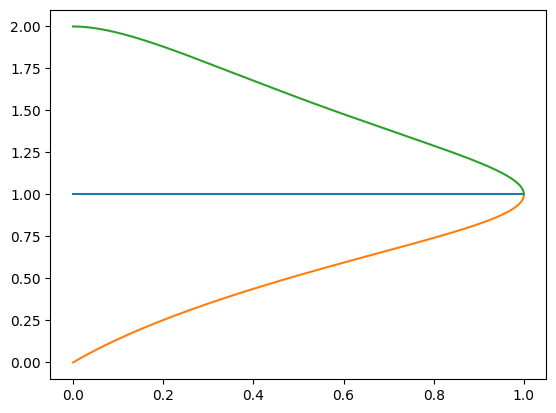

In [29]:
def diagnoseW(coll, vhat,doL):
    S = TBTPW(coll, vhat,doL=doL)

    print(f'Near: nu {S.nuN:.2f}, nd {S.ndN:.2f}, Tu {S.TuN:.2f}, Td {S.TdN:.2f}')
    print(f'Far: nu {S.nuF:.2f}, nd {S.ndF:.2f}, Tu {S.TuF:.2f}, Td {S.TdF:.2f}')

    S.plot_far_sol_profiles()
    if False:
        plt.figure()
        for d,lab in zip([S.nuF, S.ndF, S.TuF, S.TdF],
                         ['nuF','ndF','TuF','TdF']):
            plt.plot(S.t[-1],d,label=lab)
        #for d,lab in zip([S.nuF_stationary, S.ndF_stationary, S.TuF_stationary, S.TdF_stationary],
        #                 ['nuF_s','ndF_s','TuF_s','TdF_s']):
        #    plt.plot(S.t[-1],d,'o',label=lab)
        plt.axhline(1,c='k',ls=':',label='n')

diagnoseW(1,0.1,1/3)

In [30]:
# vhat, coll_max:
# 0.5, 17 (acts wierdly in near SOL)
# 0.1, 23
# 0.01, 35


def store_vals(coll_arr, vhat):
    D = np.zeros([7,coll_arr.size])

    for i in range(coll_arr.size):
        S = TBTPW(coll_arr[i],vhat, doL=1/3)
        D[0,i] = S.ndN
        D[1,i] = S.TuN
        D[2,i] = S.TdN
        D[3,i] = S.nuF
        D[4,i] = S.ndF
        D[5,i] = S.TuF
        D[6,i] = S.TdF

    return D

Nu = np.linspace(1,23,50)
D = store_vals(Nu,0.1)

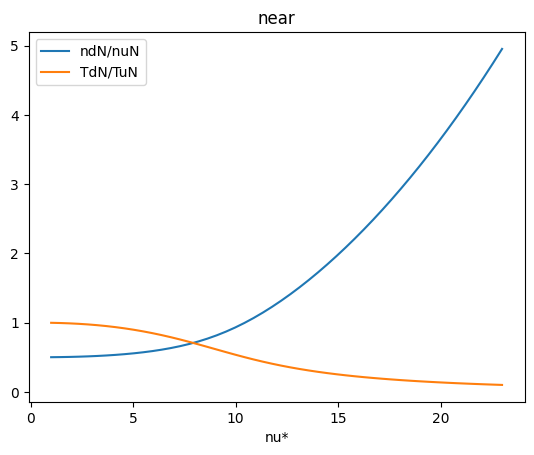

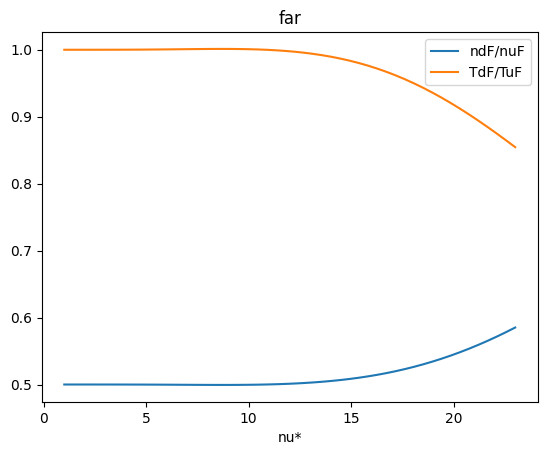

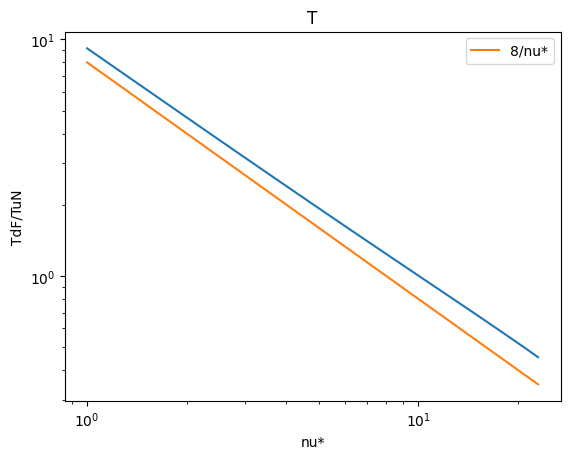

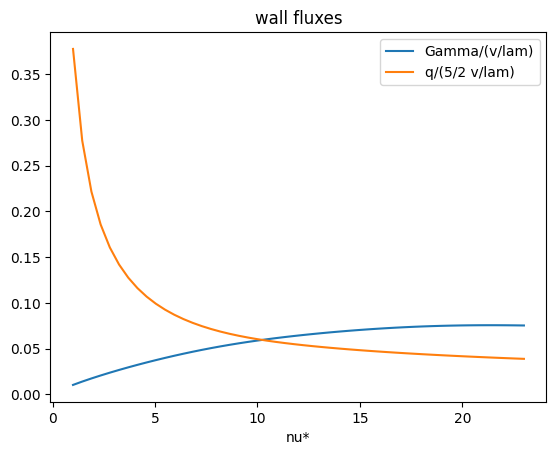

In [32]:
def plot_data():
    plt.figure('near')
    plt.title('near')
    plt.plot(Nu, D[0,:], label='ndN/nuN')
    plt.plot(Nu, D[2,:]/D[1,:], label='TdN/TuN')
    plt.legend()
    plt.xlabel('nu*')
    plt.savefig('near.png')

    plt.figure('far')
    plt.title('far')
    plt.plot(Nu, D[4,:]/D[3,:], label='ndF/nuF')
    plt.plot(Nu, D[6,:]/D[5,:], label='TdF/TuF')
    plt.legend()
    plt.xlabel('nu*')
    plt.savefig('far.png')
    
    plt.figure('T')
    plt.title('T')
    plt.loglog(Nu, D[6,:]/D[1,:])
    plt.plot(Nu,8/Nu,label='8/nu*')
    plt.legend()
    plt.xlabel('nu*')
    plt.ylabel('TdF/TuN')
    plt.savefig('T.png')
    
    plt.figure('wall fluxes')
    plt.title('wall fluxes')
    plt.plot(Nu, D[3,:], label='Gamma/(v/lam)')
    plt.plot(Nu, D[3,:]*D[5,:],label='q/(5/2 v/lam)')
    plt.legend()
    plt.xlabel('nu*')
    plt.savefig('wall.png')
plot_data()

In [ ]:
def diagnose(coll, uhat,doL):
    S = TBTP(coll, uhat,doL=doL)


    print(f'Near: nu {S.nuN:.2f}, nd {S.ndN:.2f}, Tu {S.TuN:.2f}, Td {S.TdN:.2f}')
    print(f'Far: nu {S.nuF:.2f}, nd {S.ndF:.2f}, Tu {S.TuF:.2f}, Td {S.TdF:.2f}')
    #S.solve_far_sol(tmax=50)
    if False:
        plt.figure()
        for d,lab in zip([S.nuF, S.ndF, S.TuF, S.TdF],
                         ['nuF','ndF','TuF','TdF']):
            plt.plot(S.t[-1],d,label=lab)
        #for d,lab in zip([S.nuF_stationary, S.ndF_stationary, S.TuF_stationary, S.TdF_stationary],
        #                 ['nuF_s','ndF_s','TuF_s','TdF_s']):
        #    plt.plot(S.t[-1],d,'o',label=lab)
        plt.axhline(1,c='k',ls=':',label='n')

diagnose(1,0.1,1/3)

In [ ]:

    def _far_sol_system(self,t,x):
        """
        The dynamical system to solve in the far SOL. We define it as A dx/dt = b, where 
        x = [nuF, ndF, TdF] (all far SOL)
        and A and b are given by the equations above. Tu is replaced through the heat flux equation.
        
        Solving the linear system gives dx/dt

        This is likely bad - must be rederived.
        """
        nuF,ndF,TdF = x
    
        TuF = (TdF**3.5 + 0.5*self.ghat*self.xi*ndF*TdF**1.5)**(2/7)
    
    
        A = np.array([[1,1,0],
                      [0,TdF**0.5,0.5*ndF*TdF**(-0.5)],
                      [1.5*TuF, 
                       2*TdF + (3/14)*self.ghat*self.xi*nuF*TuF**(-2.5)*TdF**1.5,
                       2*ndF + (3/7)*nuF*TuF**(-2.5)*(3.5*TdF**2.5+0.75*self.ghat*self.xi*ndF*TdF**0.5)]])
    
        b = np.array([self.vhat-ndF*TdF**0.5,
                      nuF*TuF-2*ndF*TdF,
                      2.5*self.vhat*self.TuN-(self.ghat+3)*ndF*TdF**1.5])
    
        return np.linalg.solve(A,b)

    def solve_far_sol_fluct(self,tmax=10,x0=[1.,0.5,0.5]):
        #if x0:
        #    X0 = x0
        #else:
        #    X0 = [self.nuF_stationary,self.ndF_stationary,self.TdF_stationary]
        S = solve_ivp(self._far_sol_system, [0,tmax],x0)

        self.t = S.t
        self.nuF = S.y[0,:]
        self.ndF = S.y[1,:]
        self.TdF = S.y[2,:]
        
        self.TuF = (self.TdF**3.5 + 0.5*self.ghat*self.xi*self.ndF*self.TdF**1.5)**(2/7)
uN')
        plt.axhline(S.TuN,c='grey',ls='--',label='TuN')
        plt.xlabel('t')
        plt.legend()
    print(f'TuN:{S.TuN}, TdN/TuN:{S.TdN/S.TuN}, ndN:{S.ndN}')
    print(f'TuF:{S.TuF}, TdF:{S.TdF}, nuF:{S.nuF}, ndF:{S.ndF}')


In [ ]:
# Test that the collisionality function is correct. It is a little on the high side

In [ ]:
def system(t,x,sigma,K,gamma=7,tau=1,nuhat=0.5):
    """
    The dynamical system to solve. We define it as A dx/dt = b, where x = [nu,nt,Tt]
    and A and b are given by the equations above. Solving the linear system gives dx/dt
    """
    nu,nt,Tt = x

    c0 = 7*gamma*nuhat/(4*3.2*(1+tau)**3.5)
    Tu = (Tt**3.5 + c0*nt*Tt**1.5)**(2/7)


    A = np.array([[1,1,0],
                  [0,Tt**0.5,0.5*nt*Tt**(-0.5)],
                  [1.5*Tu, 2*Tt + (3/7)*nu*Tu**(-2.5)*c0*Tt**1.5, 2*nt + (3/7)*nu*Tu**(-2.5)*c0*(2.5*Tt**2.5+1.5*c0*Tt**1.5*nt)]])

    b = np.array([sigma-nt*Tt**0.5,
                  nu*Tu-2*nt*Tt,
                  K+(gamma/(1+tau)**1.5-3)*nt*Tt**1.5])

    return np.linalg.solve(A,b)

class TwoPointFarSOL:
    def __init__(self, S=1., K=1., nuhat=0.5, gamma=7., tau=1.):
        self.S = S
        self.K = K
        self.nuhat = nuhat
        self.gamma=gamma
        self.tau=tau

    def solve(self,tmax=10,x0=[1,0.5,0.5]):
        S = solve_ivp(system, [0,tmax],x0,args=(self.S, self.K, self.gamma, self.tau,self.nuhat))

        self.t = S.t
        self.nu = S.y[0,:]
        self.nt = S.y[1,:] This gives
nd,F
pTd,F = ˆv

1 − e−1/ˆδ 
,
ˆγξnd,FT 3/2
d,F = 5
2 ˆv

1 − e−1/ˆδ 
Tu,N,
which may be combined to give equations for nd,F and Td,F purely in terms of
model parameters and upstream co
        self.Tt = S.y[2,:]
        
        c0 = 7*self.gamma*self.nuhat/(4*3.2*(1+self.tau)**3.5)
        self.Tu = (self.Tt**3.5 + c0*self.nt*self.Tt**1.5)**(2/7)
        

M = TwoPointFarSOL(S=10)
M.solve(tmax=1000)

plt.figure()
plt.plot(M.t, M.nt/M.nu, label='nt/nu')
plt.plot(M.t, M.Tt/M.Tu, label='Tt/Tu')
plt.legend()

In [ ]:
@jit
def phi(x):
    if x>0:
        return x*np.exp(-x)
    return 0

@jit
def FPP(t,td,s,A):
    res = 0
    for k in range(s.size):
        res += A[k]*phi((t-s[k])/td)
    return res

@jit
def FPP_array(tb,td,s,A):
    Phi = np.zeros_like(tb)
    for i in range(len(tb)):
        Phi[i] = FPP(tb[i],td,s,A)
    return Phi

In [ ]:
class TwoPointFluct:
    def __init__(self, tmax=10., q_mean=1., Q=1.,
                 fluct = True, td=1e-1, gamma=1., A_mean=1):

        # q = q_b + q_fpp, so <q> = q_b + gamma <A>. 
        # Thus q = <q> ( 1+ (q_fpp-gamma<A>)/<q>) which requires 
        # <A> < <q>/gamma to be positive.

        if fluct==True:
            assert(gamma*A_mean<q_mean),'The forcing should be positive'
        
        self.tmax=tmax
        
        self.q_mean = q_mean
        self.Q = Q
        
        self.fluct = fluct
        self.td = td
        self.gamma = gamma
        self.A_mean = A_mean

    
    def realize_fpp(self,tmax):
        tw = self.td/self.gamma
        # Define the FPP a little outside of the domain to avoid issues with solve_ivp hitting boundaries
        K = np.random.poisson(1.02*tmax/tw)
        self.s = np.random.uniform(-0.01*tmax,1.01*tmax,size=K)
        self.A = self.A_mean*np.random.exponential(size=K)


        
    def run(self,tmax=10,Tt_init=0.1, dt_over_td=0.1):
        if self.fluct:
            self.realize_fpp(tmax)
            q = lambda t: self.q_mean*( 1+( FPP(t,self.td,self.s,self.A)-self.gamma*self.A_mean )/self.q_mean )
        else:
            q = lambda t: self.q_mean

        def Tu(Tt):
            return (Tt**(7/2)+self.Q)**(2/7)
            
        def _system(t,X):
            Tt = X[0]
            
            
            return Tt**1.5-q(t)*Tu(Tt)*Tt**2
        
        self.tb = np.arange(0,tmax,self.td*dt_over_td)
        res = solve_ivp(_system, [0,tmax], [Tt_init,], t_eval = self.tb)

        self.Tt = res.y[0]
        self.Tu = Tu(self.Tt)
        if self.fluct:
            self.q = self.q_mean*( 1+( FPP_array(self.tb,self.td,self.s,self.A)-self.gamma*self.A_mean )/self.q_mean )
        else:
            self.q = self.q_mean*np.ones_like(self.tb)

In [ ]:
plt.figure()
for gamma,A_mean in zip([0.1, 1, 10, 1000],[1.,0.9,0.09,0.]):
    if gamma>100:
        T = TwoPointFluct(q_mean = 1, Q=10,fluct=False)
    else:
        T = TwoPointFluct(q_mean = 1, Q=10,gamma=gamma,A_mean=A_mean)
    
    T.run(200,0.1)
    
    plt.plot(T.tb, T.Tt)
    plt.plot(T.tb, T.Tu)

    print(f'Tt mean: {T.Tt[T.tb>20].mean()}')

In [ ]:
plt.figure()
for gamma,A_mean in zip([0.1, 1, 10, 1000],[1.,0.9,0.09,0.]):
    if gamma>100:
        T = TwoPointFluct(q_mean = 1, Q=0.1,fluct=False)
    else:
        T = TwoPointFluct(q_mean = 1, Q=0.1,gamma=gamma,A_mean=A_mean)
    
    T.run(200,0.1)
    
    plt.plot(T.tb, T.Tt)
    plt.plot(T.tb, T.Tu)

    print(f'Tt mean: {T.Tt[T.tb>20].mean()}')

In [ ]:
plt.figure()
gamma = 1.
for A_mean in [0.01,0.1,0.99]:
    T = TwoPointFluct(q_mean = 1, Q=10,gamma=gamma,A_mean=A_mean)
    
    T.run(200,0.1)
    
    plt.plot(T.tb, T.Tt,label=f'<A>={A_mean}')
    plt.legend()

    print(f'Tt mean: {T.Tt[T.tb>20].mean()}')

In [ ]:
tmax = 10
td = 1e-1
gamma = 0.5
tw = td/gamma

# Generate FPP arrivals
K = np.random.poisson(tmax/tw)

s = np.random.uniform(0,tmax,size=K)
A = np.random.exponential(size=K)

    
tb = np.linspace(0,tmax,1000)
Phi = FPP_array(tb,s,A)


plt.figure()
plt.plot(tb,Phi)
plt.figure()

In [ ]:
tmax = 100
td = 1e-1
gamma = 10.
tw = td/gamma
Q = 10

res, s, A = solve_system(tmax, td, gamma,Q,[0.1,])

tb = res.t
Tt = res.y[0,:]

Tu = (Tt**(7/2)+Q)**(2/7)
    
q = FPP_array(tb,s,A)

In [ ]:
plt.plot(tb, Tt)
plt.plot(tb,Tu)
#plt.plot(tb, q)

In [ ]:
e0 = 8.8e-12
me = 9e-31
mi = 2*1.6e-27
e = 1.6e-19
cs = 1e4
n=1e19

In [ ]:
tce = 3*np.pi**1.5*e0**2*me**0.5*mi**1.5*cs**3/(10*e**(4)*n)
lam = np.sqrt(mi/me)*cs*tce

In [ ]:
tce

In [ ]:
lam

In [ ]:
np.sqrt(mi/me)*lam/10

In [ ]:
np.sqrt(me/mi)

In [ ]:
x = np.linspace(0.,10,1000)
plt.figure()
plt.plot(x,f(x,10))
plt.plot(x,f(x,1))
plt.plot(x,f(x,0.1))